In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier')
sys.path.insert(0, '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/TokenFlow')


from Tokenizer.TokenFlow import TokenFlowTokenizer
from Tiler import Tiler
from utils_benchmark import load_all_images
from Tokenizer.TokenFlow import TOKENIZER, TOKENIZER_PATH, TEACHER, IMAGE_SIZE, ENHANCED_DECODER

/users/xyixuan/miniconda3_x86/envs/decont/lib/python3.10/site-packages/torch/_subclasses/functional_tensor.py:276: UserWarning: Failed to initialize NumPy: No module named 'numpy' (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:81.)
  cpu = _conversion_method_template(device=torch.device("cpu"))


ModuleNotFoundError: No module named 'numpy'

In [5]:
tokenizer = TokenFlowTokenizer(ckpt_path=TOKENIZER_PATH, teacher=TEACHER, image_size=IMAGE_SIZE, enhanced_decoder=ENHANCED_DECODER)

Using normal pixel decoder
Final encoder config {'img_size': 432, 'patch_size': 16, 'in_chans': 3, 'num_classes': 0, 'embed_dim': 1152, 'depth': 12, 'num_heads': 12, 'mlp_ratio': 4.0, 'qkv_bias': True, 'qk_scale': None, 'drop_rate': 0.0, 'attn_drop_rate': 0.0, 'drop_path_rate': 0.0, 'norm_layer': 'LayerNorm', 'init_values': 0.0, 'use_abs_pos_emb': True, 'use_rel_pos_bias': False, 'use_shared_rel_pos_bias': False, 'use_mean_pooling': True, 'init_scale': 0.001}
Current teacher is google/siglip-so400m-patch14-384


/users/xyixuan/miniconda3_x86/envs/openmagvit2/lib/python3.8/site-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Final decoder config {'img_size': 27, 'patch_size': 1, 'in_chans': 32, 'num_classes': 0, 'embed_dim': 1152, 'depth': 3, 'num_heads': 12, 'mlp_ratio': 4.0, 'qkv_bias': True, 'qk_scale': None, 'drop_rate': 0.0, 'attn_drop_rate': 0.0, 'drop_path_rate': 0.0, 'norm_layer': 'LayerNorm', 'init_values': 0.0, 'use_abs_pos_emb': True, 'use_rel_pos_bias': False, 'use_shared_rel_pos_bias': False, 'use_mean_pooling': True, 'init_scale': 0.001}
no kmeans init
Current model is: TokenFlow with teacher siglip_384, initialization finished.


In [6]:
# Load image paths
folder_path = '../assets/original'
images, image_names, image_paths = load_all_images(folder_path)

Loaded: graph_theory1.png
Loaded: line_chart.png
Loaded: logo1.png
Loaded: logo2.png
Loaded: math_draft1.png
Loaded: menu.jpeg
Loaded: mri_human_brain.png
Loaded: physics1.png
Loaded: physics2.png
Loaded: tcp_1.png


In [8]:
TILE_SIZE = 384
tiler = Tiler(tile_size=TILE_SIZE, pad_value=-1.0, tile_resize=IMAGE_SIZE)

Linear scaling ratio: 384/384 = 1.000
Pixel per tile ratio: 384²/384² = 1.000
No pixel change: same resolution processing


Original image: 3×2100×1400
Downsampling to: 2100×1400 (ratio: 1.000)
Padding to: 2304×1536
Creating 6×4 = 24 tiles of 384×384
Showing 6×4 = 24 tiles


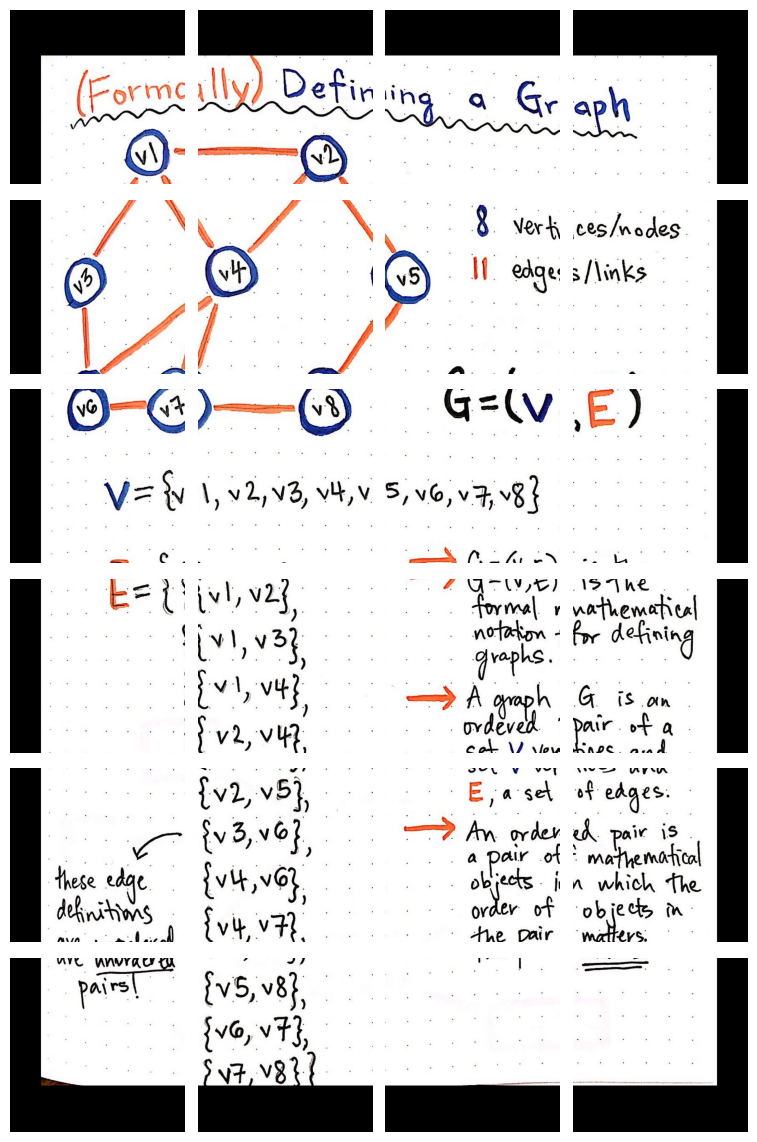

In [9]:
image = images[0]
res = tiler(image)
tiler.show_tiles(res['tiles'], res['metadata'])

In [10]:
image_tensor = tokenizer.preprocess(image).squeeze(0)
image_tiled = tiler(image_tensor)['tiles'].to('cuda')

Original image: 3×2100×1400
Downsampling to: 2100×1400 (ratio: 1.000)
Padding to: 2304×1536
Creating 6×4 = 24 tiles of 384×384


In [11]:
import torch

with torch.no_grad():
    latent, _, indices = tokenizer.model.encode(image_tiled)

In [20]:
first_tile_indices  = indices[0:1]
second_tile_indices = indices[1:2]

In [18]:
first_tile_indices

tensor([[16374, 32478, 13194,  ..., 16148, 20126,   297]], device='cuda:0')

In [19]:
second_tile_indices

tensor([[ 3775, 22333, 13278,  ..., 26842, 30162,  7192]], device='cuda:0')

In [51]:
tile_indices

tensor([[16374, 32478, 13194,  ..., 16148, 20126,   297]], device='cuda:0')

In [52]:
with torch.no_grad():
    output = tokenizer.model.decode_code(tile_indices)
    if isinstance(output, tuple):
        output = output[1]

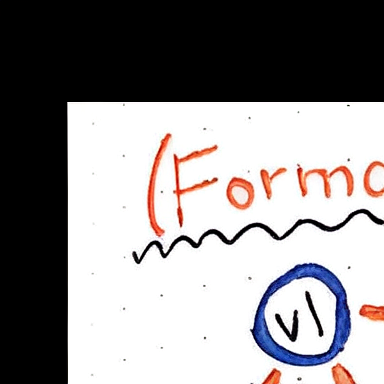

In [53]:
reconstructed_image = tokenizer.postprocess(output)
reconstructed_image.show()

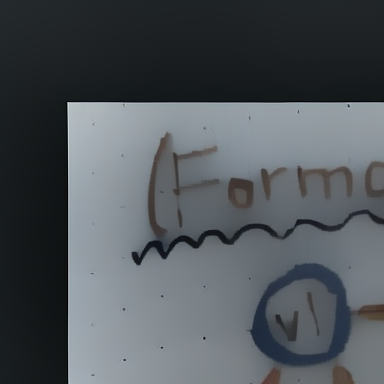

In [ ]:
token_id = 32478
length = tile_indices.shape[-1]  # assuming tile_indices.shape = (B, L) for 1D
half_length = length // 10

# Clone the first element (shape: L)
indices_clone = tile_indices[0].clone()

# Replace first half
indices_clone[:half_length] = token_id

reconstructed = tokenizer.decode(indices_clone.unsqueeze(0))
tokenizer.postprocess(reconstructed)

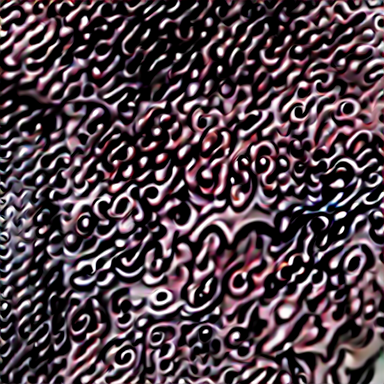

In [75]:
half_length = length // 2

# Clone the first element (shape: L)
indices_clone = tile_indices[0].clone()

# Duplicate second half to first half
indices_clone[:half_length] = indices_clone[half_length:half_length*2]

reconstructed = tokenizer.decode(indices_clone.unsqueeze(0))
tokenizer.postprocess(reconstructed)

In [51]:
# Get the length of indices for each tile
length = first_tile_indices.shape[-1]
half_length = length // 2

# Get second half of first tile and first half of second tile
first_tile_part = first_tile_indices[0, half_length:]
second_tile_part = second_tile_indices[0, :half_length]

# Concatenate them to create a new tile
combined_indices = torch.cat([second_tile_part, first_tile_part]).unsqueeze(0)

print(f"Original tile length: {length}")
print(f"Half length: {half_length}")
print(f"Combined indices shape: {combined_indices.shape}")

Original tile length: 2227
Half length: 1113
Combined indices shape: torch.Size([1, 2227])


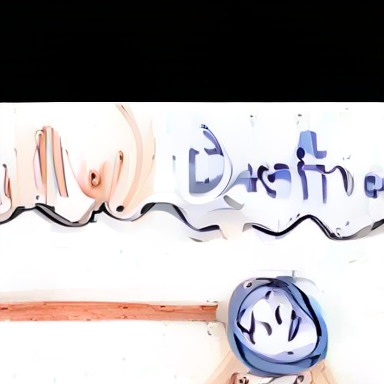

In [52]:
# Decode and reconstruct
with torch.no_grad():
    reconstructed = tokenizer.decode(combined_indices)
    
# Postprocess to get the image
reconstructed_image = tokenizer.postprocess(reconstructed)
reconstructed_image